1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Tuberculosis
Tuberculosis detected! Generating Grad-CAM visualization...


C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


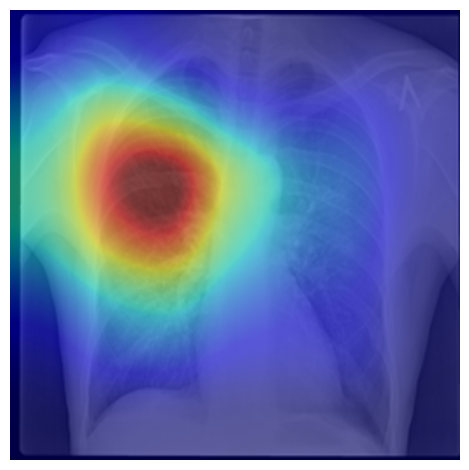

In [1]:
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from torchvision.io import read_image
from torchvision.models import resnet18
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-18.png"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

if label == "Tuberculosis":
    print("Tuberculosis detected! Generating SmoothGrad-CAM visualization...")

    torch_model = resnet18(pretrained=True).eval()

    img = read_image(img_path)

    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ConvertImageDtype(torch.float),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    input_tensor.requires_grad = True  # Enable gradients

    cam_extractor = SmoothGradCAMpp(torch_model, target_layer="layer4")

    out = torch_model(input_tensor)

    class_idx = out.squeeze(0).argmax().item()
    activation_map = cam_extractor(class_idx, out)

    result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)

    plt.imshow(result)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("Normal case detected.")

    original_img = image.load_img(img_path)
    plt.imshow(original_img)
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Tuberculosis
Tuberculosis detected! Generating Grad-CAM visualization...


C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


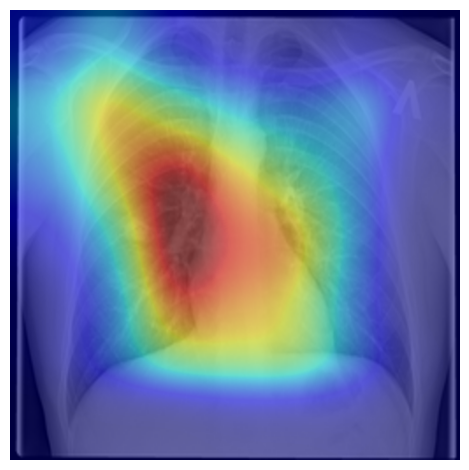

In [1]:
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from torchvision.io import read_image
from torchvision.models import resnet18
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-92.png"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

if label == "Tuberculosis":
    print("Tuberculosis detected! Generating Grad-CAM visualization...")

    torch_model = resnet18(pretrained=True).eval()

    img = read_image(img_path)

    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ConvertImageDtype(torch.float),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    input_tensor.requires_grad = True  # Enable gradients

    cam_extractor = SmoothGradCAMpp(torch_model, target_layer="layer4")

    out = torch_model(input_tensor)

    class_idx = out.squeeze(0).argmax().item()
    activation_map = cam_extractor(class_idx, out)

    result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)

    plt.imshow(result)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("Normal case detected.")

    original_img = image.load_img(img_path)
    plt.imshow(original_img)
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Tuberculosis
Tuberculosis detected! Generating Grad-CAM visualization...


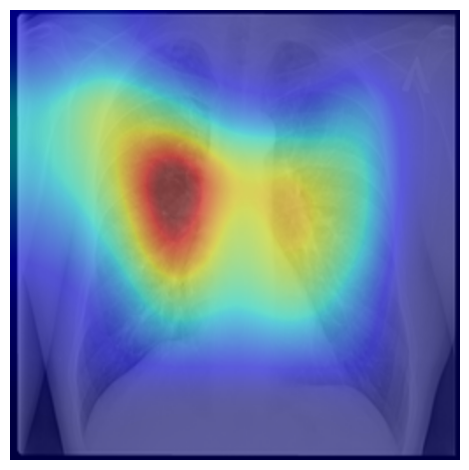

In [13]:
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from torchvision.io import read_image
from torchvision.models import resnet18
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-21.png"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

if label == "Tuberculosis":
    print("Tuberculosis detected! Generating Grad-CAM visualization...")

    torch_model = resnet18(pretrained=True).eval()

    img = read_image(img_path)

    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ConvertImageDtype(torch.float),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    input_tensor.requires_grad = True  # Enable gradients

    cam_extractor = SmoothGradCAMpp(torch_model, target_layer="layer4")

    out = torch_model(input_tensor)

    class_idx = out.squeeze(0).argmax().item()
    activation_map = cam_extractor(class_idx, out)

    result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)

    plt.imshow(result)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("Normal case detected.")

    original_img = image.load_img(img_path)
    plt.imshow(original_img)
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Normal
Normal case detected.


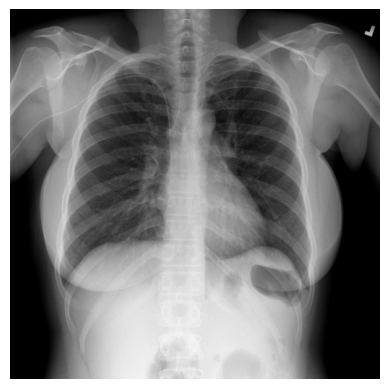

In [2]:
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from torchvision.io import read_image
from torchvision.models import resnet18
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-13.png"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

if label == "Tuberculosis":
    print("Tuberculosis detected! Generating SmoothGrad-CAM visualization...")

    torch_model = resnet18(pretrained=True).eval()

    img = read_image(img_path)

    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ConvertImageDtype(torch.float),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    input_tensor.requires_grad = True  # Enable gradients

    cam_extractor = SmoothGradCAMpp(torch_model, target_layer="layer4")

    out = torch_model(input_tensor)

    class_idx = out.squeeze(0).argmax().item()
    activation_map = cam_extractor(class_idx, out)

    result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)

    plt.imshow(result)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("Normal case detected.")

    original_img = image.load_img(img_path)
    plt.imshow(original_img)
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Tuberculosis
Tuberculosis detected! Generating Grad-CAM visualization...


C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


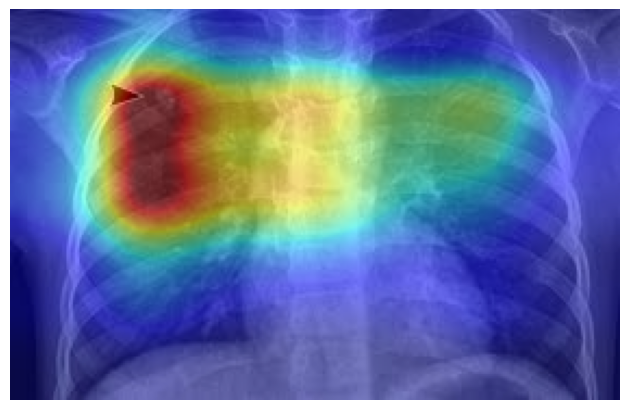

In [2]:
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from torchvision.io import read_image
from torchvision.models import resnet18
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

img_path = r"C:\MAJOR\Dataset\images.jpeg"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

if label == "Tuberculosis":
    print("Tuberculosis detected! Generating SmoothGrad-CAM visualization...")

    torch_model = resnet18(pretrained=True).eval()

    img = read_image(img_path)

    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ConvertImageDtype(torch.float),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    input_tensor.requires_grad = True  # Enable gradients

    cam_extractor = SmoothGradCAMpp(torch_model, target_layer="layer4")

    out = torch_model(input_tensor)

    class_idx = out.squeeze(0).argmax().item()
    activation_map = cam_extractor(class_idx, out)

    result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)

    plt.imshow(result)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("Normal case detected.")

    original_img = image.load_img(img_path)
    plt.imshow(original_img)
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Tuberculosis
Tuberculosis detected! Generating SmoothGrad-CAM++ visualization...


C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


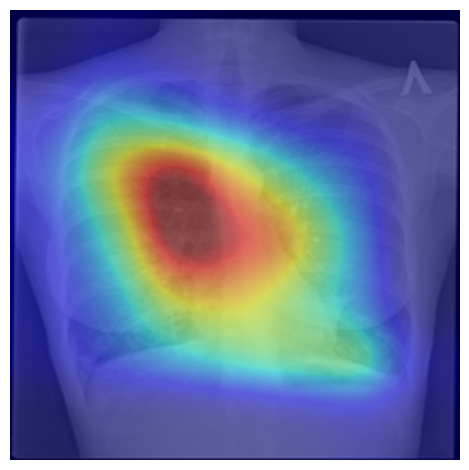

In [1]:
import numpy as np
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from torchvision.io import read_image
from torchvision.models import resnet18
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

model = load_model("ResNet.h5")  # Ensure this is your fine-tuned ResNet model

def preprocess_image(img_path, target_size=(224, 224)):  
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Load image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Apply ResNet50 preprocessing
    return img_array

def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  
    prediction = model.predict(processed_image)  # Get prediction

    # Handling both softmax and sigmoid outputs
    if prediction.shape[-1] == 2:  # Softmax case
        predicted_class = np.argmax(prediction)  
        probability = prediction[0][predicted_class]
    else:  # Sigmoid case (Binary classification)
        probability = prediction[0][0]
        predicted_class = int(probability > threshold)

    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return probability, class_label

img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-30.png"
probability, label = predict_tb(img_path, model)

print(f"Prediction: {label}")

if label == "Tuberculosis":
    print("Tuberculosis detected! Generating SmoothGrad-CAM++ visualization...")

    torch_model = resnet18(pretrained=True).eval()

    img = read_image(img_path)

   
    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)


    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ConvertImageDtype(torch.float),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


    input_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    input_tensor.requires_grad = True  # Enable gradients


    cam_extractor = SmoothGradCAMpp(torch_model, target_layer="layer4")

    out = torch_model(input_tensor)

    class_idx = out.squeeze(0).argmax().item()
    activation_map = cam_extractor(class_idx, out)

    result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)

    plt.imshow(result)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("Normal case detected.")

    original_img = image.load_img(img_path)
    plt.imshow(original_img)
    plt.axis('off')
    plt.show()